**Ноутбук структурирован в виде трех независимых логических модулей, что позволяет использовать модель как в режиме повторного обучения, так и в режиме готового инференса без изменения кода.**

# **Раздел 1. Подготовка данных (опционально)**

**Данный раздел используется только в случае необходимости обучения или дообучения модели.**

**Если используется уже обученная модель, раздел может быть пропущен.**

В качестве обучающей базы используется открытый датасет: Roboflow Drowsiness Detection. Датасет содержит размеченные изображения лиц с различными состояниями глаз и подходит для задач детекции и классификации.



## 1.1 Загрузка и разархивация датасета

In [ ]:
import zipfile
import os

def extract_dataset(zip_path, extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Готово! Распаковано в:", extract_dir)

zip_path = "/content/Drowsiness detection.v2i.yolov8.zip"
extract_dir = "/content/drowsiness_dataset"

extract_dataset(zip_path, extract_dir)

Готово! Распаковано в: /content/drowsiness_dataset


## 1.2 Приведение YOLO-датасета к структуре классификации

In [ ]:
import os
import shutil

# Исходный датасет
BASE_DIR = '/content/drowsiness_dataset'

# Новая структура для корректного flow_from_directory
NEW_BASE_DIR = '/content/drowsiness_dataset_split'

splits = ['train', 'valid', 'test']

for split in splits:
    images_path = os.path.join(BASE_DIR, split, 'images')
    labels_path = os.path.join(BASE_DIR, split, 'labels')

    # Создаём новые папки для split
    for cls in ['0', '1']:
        os.makedirs(os.path.join(NEW_BASE_DIR, split, cls), exist_ok=True)

    # Перебираем все изображения
    for img_name in os.listdir(images_path):
        img_path = os.path.join(images_path, img_name)
        label_path = os.path.join(labels_path, img_name.replace('.jpg', '.txt'))

        # Чтение метки
        with open(label_path, 'r') as f:
            line = f.readline()
            label = line.split()[0]  # первый элемент - класс

        # Копируем изображение в соответствующую папку
        dst_path = os.path.join(NEW_BASE_DIR, split, label, img_name)
        shutil.copy2(img_path, dst_path)

print("Разделение изображений по классам завершено!")

for split in splits:
    split_path = os.path.join(NEW_BASE_DIR, split)
    class_counts = {}
    for cls in ['0', '1']:
        class_dir = os.path.join(split_path, cls)
        class_counts[cls] = len(os.listdir(class_dir))
    print(f"Распределение классов в {split}: {class_counts}")


Разделение изображений по классам завершено!
Распределение классов в train: {'0': 1985, '1': 1066}
Распределение классов в valid: {'0': 537, '1': 347}
Распределение классов в test: {'0': 279, '1': 156}


## 1.3 Формирование датасета лиц с использованием DNN OpenCV

In [ ]:
# Используем DNN на основе res10_300x300_ssd.
import os
import cv2
import shutil
import urllib.request

# -----------------------------
# Пути исходного датасета (уже разбит по классам)
# -----------------------------
INPUT_BASE = "/content/drowsiness_dataset_split"
OUTPUT_BASE = "/content/dataset_faces_dnn"
IMG_SIZE = (224, 224)

CLASS_MAP = {"0": "open", "1": "closed"}

# -----------------------------
# Скачиваем модель DNN (если не скачана)
# -----------------------------
MODEL_DIR = "/content/face_detector"
os.makedirs(MODEL_DIR, exist_ok=True)

proto_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

proto_path = os.path.join(MODEL_DIR, "deploy.prototxt")
model_path = os.path.join(MODEL_DIR, "res10_300x300_ssd_iter_140000.caffemodel")

if not os.path.exists(proto_path):
    urllib.request.urlretrieve(proto_url, proto_path)

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

# Загружаем сеть
face_net = cv2.dnn.readNetFromCaffe(proto_path, model_path)

CONF_THRESHOLD = 0.5  # минимальная уверенность детектора

# -----------------------------
# Подготовка папок
# -----------------------------
def prepare_output_dirs(base_dir):
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    for split in ["train", "valid", "test"]:
        for cls_name in ["open", "closed"]:
            os.makedirs(os.path.join(base_dir, split, cls_name), exist_ok=True)

# -----------------------------
# Обработка split
# -----------------------------
def process_split(split_name):
    print(f"Обрабатываем {split_name}...")

    split_input = os.path.join(INPUT_BASE, split_name)

    stats = {
        "total_images": 0,
        "saved": 0,
        "no_face": 0
    }

    for cls_id in ["0", "1"]:
        cls_name = CLASS_MAP[cls_id]
        class_dir = os.path.join(split_input, cls_id)

        images = [f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".png"))]

        for img_name in images:
            stats["total_images"] += 1
            img_path = os.path.join(class_dir, img_name)
            image = cv2.imread(img_path)
            if image is None:
                continue

            h, w = image.shape[:2]
            blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)),
                                         1.0, (300, 300),
                                         (104.0, 177.0, 123.0))
            face_net.setInput(blob)
            detections = face_net.forward()

            faces = []
            for i in range(detections.shape[2]):
                conf = detections[0, 0, i, 2]
                if conf < CONF_THRESHOLD:
                    continue
                box = detections[0, 0, i, 3:7] * [w, h, w, h]
                x1, y1, x2, y2 = box.astype(int)
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)
                faces.append((x1, y1, x2, y2))

            if len(faces) == 0:
                stats["no_face"] += 1
                continue  # лицо не найдено — пропускаем

            # Берём самое большое лицо
            x1, y1, x2, y2 = max(faces, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
            face_crop = image[y1:y2, x1:x2]
            face_resized = cv2.resize(face_crop, IMG_SIZE)

            save_path = os.path.join(OUTPUT_BASE, split_name, cls_name, img_name)
            cv2.imwrite(save_path, face_resized)
            stats["saved"] += 1

    # Печать статистики
    print(f"📊 Статистика {split_name}:")
    for k, v in stats.items():
        print(f"  {k}: {v}")
    if stats["total_images"] > 0:
        kept = stats["saved"] / stats["total_images"] * 100
        print(f"  ✅ Сохранено: {kept:.1f}%\n")

# -----------------------------
# Основной запуск
# -----------------------------
prepare_output_dirs(OUTPUT_BASE)

for split in ["train", "valid", "test"]:
    process_split(split)

print("✅ Чистая подготовка датасета лиц с DNN завершена!")


Обрабатываем train...
📊 Статистика train:
  total_images: 3051
  saved: 3024
  no_face: 27
  ✅ Сохранено: 99.1%

Обрабатываем valid...
📊 Статистика valid:
  total_images: 884
  saved: 870
  no_face: 14
  ✅ Сохранено: 98.4%

Обрабатываем test...
📊 Статистика test:
  total_images: 435
  saved: 432
  no_face: 3
  ✅ Сохранено: 99.3%

✅ Чистая подготовка датасета лиц с DNN завершена!


# **Раздел 2. Создание и обучение модели**

**(используется только при необходимости дообучения модели)**

Данный раздел описывает процесс обучения модели бинарной классификации лиц (состояние глаз: open / closed) на основе предварительно подготовленного датасета.
Если используется уже обученная модель, данный раздел может быть пропущен.

## 2.1 Подготовка генераторов данных

Для обучения используется ImageDataGenerator.
Для обучающей выборки применяются аугментации, для валидационной и тестовой — только нормализация.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# Параметры
# -----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------
# Аугментации для train
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

# Только нормализация для validation и test
valid_test_datagen = ImageDataGenerator(rescale=1./255)

# -----------------------------
# Генераторы
# -----------------------------
train_generator = train_datagen.flow_from_directory(
    '/content/dataset_faces_dnn/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    '/content/dataset_faces_dnn/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    '/content/dataset_faces_dnn/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("✅ Генераторы для train, valid и test готовы!")


Found 3024 images belonging to 2 classes.
Found 870 images belonging to 2 classes.
Found 432 images belonging to 2 classes.
✅ Генераторы для train, valid и test готовы!


## 2.2 Построение модели

В качестве базовой модели используется MobileNetV2 с предобученными весами ImageNet.

Архитектурные решения:

include_top=False

заморозка всех слоёв базовой модели

fine-tuning последних 20 слоёв (кроме BatchNorm)

классификатор:
GAP → Dense → Dropout → Dense → Dropout → Sigmoid

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Параметры
# -----------------------------
LEARNING_RATE = 1e-5

# -----------------------------
# Базовая модель
# -----------------------------
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

# Заморозка всех слоёв
base_model.trainable = False

# Fine-tuning последних 20 слоёв (кроме BatchNorm)
for layer in base_model.layers[-20:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# -----------------------------
# Классификатор
# -----------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# -----------------------------
# Компиляция
# -----------------------------
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 1,555,841 (5.94 MB)

 Non-trainable params: 1,063,104 (4.06 MB)

## 2.3 Учет дисбаланса классов

Для компенсации возможного дисбаланса используется class_weight.

In [ ]:
from sklearn.utils import class_weight
import numpy as np
import os

train_path = "/content/dataset_faces_dnn/train"

train_labels = []
for cls in ['open', 'closed']:
    cls_dir = os.path.join(train_path, cls)
    if os.path.exists(cls_dir):
        train_labels += [0 if cls == 'open' else 1] * len(os.listdir(cls_dir))

class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)

class_weights = {0: class_weights_values[0], 1: class_weights_values[1]}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.7679024885728797), 1: np.float64(1.4331753554502369)}


## 2.4 Обучение модели

Используются callbacks:

ModelCheckpoint — сохранение лучшей модели

EarlyStopping — предотвращение переобучения

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 20

checkpoint = ModelCheckpoint(
    'best_model_faces.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.6415 - loss: 0.6927
Epoch 1: val_accuracy improved from -inf to 0.63333, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 87s 700ms/step - accuracy: 0.6416 - loss: 0.6922 - val_accuracy: 0.6333 - val_loss: 0.5656
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6892 - loss: 0.5498
Epoch 2: val_accuracy improved from 0.63333 to 0.70460, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 414ms/step - accuracy: 0.6894 - loss: 0.5495 - val_accuracy: 0.7046 - val_loss: 0.5271
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7760 - loss: 0.4348
Epoch 3: val_accuracy improved from 0.70460 to 0.85977, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 410ms/step - accuracy: 0.7761 - loss: 0.4345 - val_accuracy: 0.8598 - val_loss: 0.3242
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8269 - loss: 0.3710
Epoch 4: val_accuracy improved from 0.85977 to 0.89655, saving model to best_model_faces.h5


...

95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 407ms/step - accuracy: 0.9205 - loss: 0.1952 - val_accuracy: 0.9368 - val_loss: 0.1523
Epoch 10/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9284 - loss: 0.1756
Epoch 10: val_accuracy improved from 0.93678 to 0.93793, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 416ms/step - accuracy: 0.9283 - loss: 0.1757 - val_accuracy: 0.9379 - val_loss: 0.1504
Epoch 11/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9287 - loss: 0.1783
Epoch 11: val_accuracy did not improve from 0.93793
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.9288 - loss: 0.1782 - val_accuracy: 0.9230 - val_loss: 0.1915
Epoch 12/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9377 - loss: 0.1521
Epoch 12: val_accuracy improved from 0.93793 to 0.94253, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 412ms/step - accuracy: 0.9377 - loss: 0.1522 - val_accuracy: 0.9425 - val_loss: 0.1484
Epoch 13/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9418 - loss: 0.1620
Epoch 13: val_accuracy improved from 0.94253 to 0.94828, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - accuracy: 0.9418 - loss: 0.1620 - val_accuracy: 0.9483 - val_loss: 0.1368
Epoch 14/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9371 - loss: 0.1624
Epoch 14: val_accuracy did not improve from 0.94828
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 403ms/step - accuracy: 0.9372 - loss: 0.1623 - val_accuracy: 0.9483 - val_loss: 0.1313
Epoch 15/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9458 - loss: 0.1530
Epoch 15: val_accuracy improved from 0.94828 to 0.94943, saving model to best_model_faces.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - accuracy: 0.9457 - loss: 0.1530 - val_accuracy: 0.9494 - val_loss: 0.1238
Epoch 16/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9421 - loss: 0.1491
Epoch 16: val_accuracy did not improve from 0.94943
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 403ms/step - accuracy: 0.9420 - loss: 0.1491 - val_accuracy: 0.9483 - val_loss: 0.1319
Epoch 17/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9414 - loss: 0.1525
Epoch 17: val_accuracy did not improve from 0.94943
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 403ms/step - accuracy: 0.9415 - loss: 0.1524 - val_accuracy: 0.9471 - val_loss: 0.1381
Epoch 18/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9533 - loss: 0.1201
Epoch 18: val_accuracy did not improve from 0.94943
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.9533 - loss: 0.1201 - val_accuracy: 0.9460 - val_loss: 0.1428
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 15.


## 2.5 Оценка качества модели

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()
loss, accuracy = model.evaluate(test_generator, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()
y_true = test_generator.classes

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Open", "Closed"]))


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9189 - loss: 0.2115
Test Loss: 0.1713
Test Accuracy: 0.9375
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

Confusion Matrix:
[[135  19]
 [  8 270]]

Classification Report:
              precision    recall  f1-score   support

        Open       0.94      0.88      0.91       154
      Closed       0.93      0.97      0.95       278

    accuracy                           0.94       432
   macro avg       0.94      0.92      0.93       432
weighted avg       0.94      0.94      0.94       432



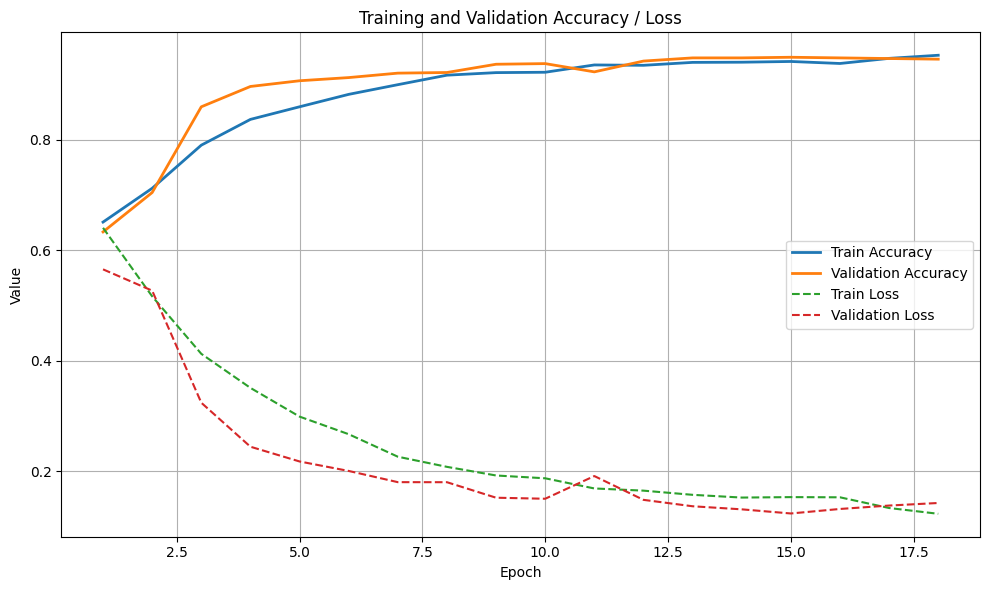

In [ ]:
# Код для красивого графика Accuracy + Loss (аккуратно, для слайдов)
import matplotlib.pyplot as plt

# history.history содержит:
# 'accuracy', 'val_accuracy', 'loss', 'val_loss'

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 6))

# Accuracy
plt.plot(epochs, acc, label='Train Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)

# Loss (вторая ось)
plt.plot(epochs, loss, linestyle='--', label='Train Loss')
plt.plot(epochs, val_loss, linestyle='--', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training and Validation Accuracy / Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 2.6 Сохранение и упаковка модели

Сохраняются:

обученная модель

class_indices генератора

архив для последующего использования в inference-пайплайне

In [ ]:
import json
import zipfile
from tensorflow.keras.models import load_model

MODEL_DIR = "/content/faces_model_package"
MODEL_PATH = os.path.join(MODEL_DIR, "faces_model.keras")
ZIP_PATH = "/content/faces_model_package.zip"

os.makedirs(MODEL_DIR, exist_ok=True)

# Сохранение модели
model.save(MODEL_PATH)

# Сохранение class_indices
class_indices = train_generator.class_indices
with open(os.path.join(MODEL_DIR, "class_indices.json"), "w") as f:
    json.dump(class_indices, f)

# Архивация
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(MODEL_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, MODEL_DIR)
            zipf.write(full_path, arcname=rel_path)

print("Модель и сопутствующие файлы сохранены и упакованы.")

Модель и сопутствующие файлы сохранены и упакованы.


# **Раздел 3. Итоговый пайплайн анализа видео**

В данном разделе описывается полный инференс-пайплайн для анализа видео с целью определения состояния водителя:
AWAKE / DROWSY / SLEEP, с генерацией тревожного сигнала при засыпании.

Пайплайн включает:

загрузку обученной модели из архива;

детекцию лица на кадрах видео;

классификацию состояния глаз;

временную агрегацию предсказаний;

принятие решения и визуализацию результата.


## 3.1 Функция загрузки модели и class mapping

Загрузка модели оформлена в виде отдельной функции, которая может вызываться из основного запускаемого модуля (main.py, app.py и т.д.).

In [ ]:
import os
import json
import zipfile
from tensorflow.keras.models import load_model

def load_faces_model_from_zip(
    zip_path: str,
    extract_dir: str = "./faces_model_package"
):
    """
    Загружает модель распознавания состояния глаз из zip-архива.

    Возвращает:
    - model: keras-модель
    - idx_to_class: отображение индекса в имя класса
    """

    if not os.path.exists(extract_dir):
        with zipfile.ZipFile(zip_path, "r") as zipf:
            zipf.extractall(extract_dir)

    model_path = os.path.join(extract_dir, "faces_model.keras")
    mapping_path = os.path.join(extract_dir, "class_indices.json")

    model = load_model(model_path)

    with open(mapping_path, "r") as f:
        class_indices = json.load(f)

    idx_to_class = {v: k for k, v in class_indices.items()}

    return model, idx_to_class


## 3.2 Инференс на одном изображении лица

Функция используется как базовый блок для классификации кропа лица.

In [ ]:
import cv2
import numpy as np

def predict_face(
    image,
    model,
    idx_to_class,
    img_size=(224, 224)
):
    """
    image: np.array (BGR) — кроп лица
    """

    img = cv2.resize(image, img_size)
    img = np.expand_dims(img.astype("float32") / 255.0, axis=0)

    prob_open = float(model.predict(img, verbose=0)[0][0])
    class_idx = int(prob_open > 0.5)

    return idx_to_class[class_idx], prob_open


## 3.3 Детекция лица (OpenCV DNN)

Для детекции используется предобученная DNN-модель OpenCV (SSD + ResNet).

In [ ]:
import urllib.request
import cv2
import os

def load_face_detector(model_dir="./face_detector"):
    os.makedirs(model_dir, exist_ok=True)

    proto_path = os.path.join(model_dir, "deploy.prototxt")
    model_path = os.path.join(
        model_dir,
        "res10_300x300_ssd_iter_140000.caffemodel"
    )

    if not os.path.exists(proto_path):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
            proto_path
        )

    if not os.path.exists(model_path):
        urllib.request.urlretrieve(
            "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/"
            "res10_300x300_ssd_iter_140000.caffemodel",
            model_path
        )

    return cv2.dnn.readNetFromCaffe(proto_path, model_path)


In [ ]:
def detect_face(frame, face_net, conf_threshold=0.5):
    h, w = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(frame, (300, 300)),
        1.0,
        (300, 300),
        (104.0, 177.0, 123.0)
    )

    face_net.setInput(blob)
    detections = face_net.forward()

    faces = []
    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf < conf_threshold:
            continue

        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        x1, y1, x2, y2 = box.astype(int)

        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        faces.append((x1, y1, x2, y2))

    if not faces:
        return None, None

    x1, y1, x2, y2 = max(
        faces,
        key=lambda b: (b[2]-b[0])*(b[3]-b[1])
    )

    return frame[y1:y2, x1:x2], (x1, y1, x2, y2)


## 3.4 Основной видеопайплайн

**Логика определения состояния водителя**

Используется временное окно и счётчик закрытых глаз.

Состояния:

AWAKE — глаза открыты

DROWSY — частое закрытие глаз

SLEEP — глаза закрыты ≥ 1.5 секунды → тревога

In [ ]:
from collections import deque
from IPython.display import Audio, display, clear_output
from google.colab.patches import cv2_imshow

def generate_beep(duration=0.5, freq=1000, sample_rate=44100):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    tone = np.sin(freq * t * 2 * np.pi)
    return Audio(tone, rate=sample_rate, autoplay=True)


In [ ]:
def process_video(
    video_path,
    model,
    face_net,
    img_size=(224, 224),
    window_size=15,
    drowsy_threshold=0.6,
    sleep_seconds=1.5,
    display_every=20,
    display_scale=0.5
):
    """
    Обрабатывает видеофайл для детекции сонливости водителя по состоянию глаз.

    Функция читает видео покадрово, детектирует лицо, извлекает область глаз,
    накапливает предсказания модели в скользящем окне и определяет состояние
    сонливости на основе временного порога.

    Parameters
    ----------
    video_path : str
        Путь к видеофайлу для обработки.
    model : torch.nn.Module
        Обученная модель классификации состояния глаз (open / closed).
    face_net : cv2.dnn_Net
        Модель детекции лица (OpenCV DNN).
    img_size : tuple of int, optional
        Размер входного изображения для модели (width, height).
        По умолчанию (224, 224).
    window_size : int, optional
        Размер скользящего окна (в кадрах) для сглаживания предсказаний.
        По умолчанию 15.
    drowsy_threshold : float, optional
        Порог доли закрытых глаз в окне, после которого состояние
        считается сонливостью. Значение в диапазоне [0, 1].
        По умолчанию 0.6.
    sleep_seconds : float, optional
        Минимальное время (в секундах), в течение которого глаза
        должны быть закрыты для фиксации засыпания.
        По умолчанию 1.5.
    display_every : int, optional
        Частота отображения кадров (каждый N-й кадр).
        Используется для снижения нагрузки при визуализации.
        По умолчанию 20.
    display_scale : float, optional
        Масштаб отображаемого кадра при визуализации.
        Значение < 1 уменьшает изображение.
        По умолчанию 0.5.

    Returns
    -------
    None
        Функция не возвращает значение.
        Результаты выводятся визуально и/или в консоль.
    """


    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Ошибка при открытии видео")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    fps = fps if fps and fps > 0 else 25
    sleep_frames = int(sleep_seconds * fps)

    window = deque(maxlen=window_size)
    closed_streak = 0
    alarm_active = False
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        face_crop, face_box = detect_face(frame, face_net)

        if face_crop is None:
            frame_count += 1
            continue

        # --- подготовка лица ---
        face = cv2.resize(face_crop, img_size)
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face = np.expand_dims(face.astype("float32") / 255.0, axis=0)

        prob_open = float(model.predict(face, verbose=0)[0][0])
        prob_closed = 1.0 - prob_open

        eye_closed = int(prob_closed >= 0.5)
        window.append(eye_closed)

        closed_streak = closed_streak + 1 if eye_closed else 0
        drowsy_ratio = sum(window) / len(window)

        # --- состояние ---
        if closed_streak >= sleep_frames:
            status = "SLEEP"
        elif drowsy_ratio >= drowsy_threshold:
            status = "DROWSY"
        else:
            status = "AWAKE"

        # --- сигнал ---
        if status == "SLEEP":
            if not alarm_active:
                display(generate_beep())
                alarm_active = True
        else:
            alarm_active = False

        # --- визуализация ---
        vis = frame.copy()

        color = (0, 255, 0)
        if status == "DROWSY":
            color = (0, 255, 255)
        elif status == "SLEEP":
            color = (0, 0, 255)

        x1, y1, x2, y2 = face_box
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

        cv2.putText(vis, f"Status: {status}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.putText(vis, f"Prob closed: {prob_closed:.2f}", (10, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

        cv2.putText(vis, f"Closed frames: {closed_streak}", (10, 110),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 200), 2)

        cv2.putText(vis, f"Drowsy ratio: {drowsy_ratio:.2f}", (10, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (180, 180, 255), 2)

        if status == "SLEEP":
            cv2.putText(vis, "ALARM ON", (10, 190),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 255), 3)

        # --- уменьшенное отображение ---
        if frame_count % display_every == 0:
            h, w = vis.shape[:2]
            vis_small = cv2.resize(
                vis,
                (int(w * display_scale), int(h * display_scale))
            )
            clear_output(wait=True)
            cv2_imshow(vis_small)

        frame_count += 1

    cap.release()
    print("Обработка видео завершена")


## 3.5 Запуск пайплайна

In [ ]:
model, idx_to_class = load_faces_model_from_zip(
    zip_path="/content/faces_model_package.zip"
)

face_net = load_face_detector()


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 15 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


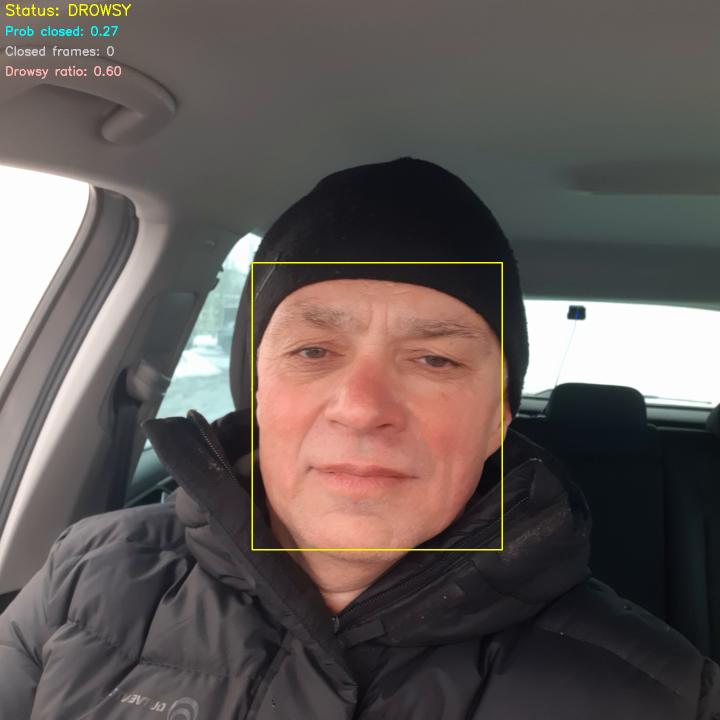

Обработка видео завершена


In [ ]:
process_video(
    video_path="/content/test_video_32.mp4",
    model=model,
    face_net=face_net
)


In [ ]:
# @title
model, idx_to_class = load_faces_model_from_zip(
    zip_path="/content/faces_model_package.zip"
)

face_net = load_face_detector()

process_video(
    video_path="/content/test_video_32.mp4",
    model=model,
    face_net=face_net
)
